## Function 2
Optimisation task- Maximisation.
description of balckbox function-	
Imagine a black box, or a mystery ML model, that takes two numbers as input and returns a log-likelihood score. Your goal is to maximise that score, but each output is noisy, and depending on where you start, you might get stuck in a local optimum. 
To tackle this, you use Bayesian optimisation, which selects the next inputs based on what it has learned so far. It balances exploration with exploitation, making it well suited to noisy outputs and complex functions with many local peaks.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.gaussian_process import GaussianProcessRegressor
from scipy.stats.qmc import LatinHypercube
from scipy.stats import uniform, loguniform, norm
from sklearn.gaussian_process.kernels import Matern, RBF, WhiteKernel, ConstantKernel as C
from scipy.optimize import minimize
import warnings
from sklearn.exceptions import ConvergenceWarning

In [2]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C, WhiteKernel
from scipy.stats import norm
from scipy.optimize import minimize
import warnings

warnings.filterwarnings("ignore")

# --- 1. DATA RECONSTRUCTION ---

# Initial 10 points
initial_inputs = np.array([
    [0.66579958, 0.12396913], [0.87779099, 0.7786275 ], [0.14269907, 0.34900513],
    [0.84527543, 0.71112027], [0.45464714, 0.29045518], [0.57771284, 0.77197318],
    [0.43816606, 0.68501826], [0.34174959, 0.02869772], [0.33864816, 0.21386725],
    [0.70263656, 0.9265642 ] #best inputs 
])
initial_outputs = np.array([
    0.53899612, 0.42058624, -0.06562362, 0.29399291, 0.21496451, 0.02310555,
    0.24461934, 0.03874902, -0.01385762, 0.61120522 # best score
])

# Weekly Data 
X_weeks = np.array([
    [0.70263656, 0.9265642],  # W1 
    [0.9813253, 0.97405327],  # W2
    [0.747732, 0.157155],     # W3
    [0.689122, 0.032539],     # W4
    [0.0, 1.0],               # W5
    [0.671861, 1.000000],     # W6
    [0.236940, 0.017636],     # W7
    [0.706424, 1.000000],     # W8
    [0.698908, 1.000000],     # W9 
    [0.701377, 0.987536],     #w10 
    [0.699898, 0.960000]     #w11
    
])
Y_weeks = np.array([
    0.58720925, 0.02672407, 0.39895242, 0.52526682, 0.05677768, 0.53542298,
    0.01069429, 0.55940237, 0.53891290, 0.54542898, 0.59717108902
])

# Combine Data
X_data = np.vstack([initial_inputs, X_weeks])
Y_data = np.append(initial_outputs, Y_weeks)

print(f"Total Data Points: {len(X_data)}")
best_idx = np.argmax(Y_data)
best_X = X_data[best_idx]
best_Y = Y_data[best_idx]
print(f"Global Best: {best_Y:.6f} at {np.round(best_X, 6)}")

##################################################################

# --- 2. Fit GP Model ---
# ARD allows different length scales for X1 and X2
kernel = C(1.0) * Matern(length_scale=[0.1, 0.1], nu=2.5) + WhiteKernel(noise_level=0.01)

gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=20,
    normalize_y=True,
    random_state=42
)

gp.fit(X_data, Y_data)

# --- 3. Acquisition Function (EI) ---
def expected_improvement(X, gp, best_y, xi=0.001):
    X = X.reshape(1, -1)
    mu, sigma = gp.predict(X, return_std=True)
    
    with np.errstate(divide='warn'):
        imp = mu - best_y - xi
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return -ei.flatten()

# --- 4. Trust Region Optimization ---
# We define a gap between the Best (0.926) and Week 11 (0.960)
bounds = [
    (0.69, 0.71),  # X1: Keep strictly near 0.70
    (0.92, 0.96)   # X2: Explore the gap between our two best points
]

best_acq = np.inf
next_point = None

# Run optimization with multiple restarts
for _ in range(50):
    x0 = np.random.uniform([b[0] for b in bounds], [b[1] for b in bounds])
    res = minimize(
        expected_improvement, 
        x0=x0, 
        bounds=bounds, 
        method='L-BFGS-B',
        args=(gp, best_Y, 0.001)
    )
    
    if res.fun < best_acq:
        best_acq = res.fun
        next_point = res.x

print("\n--- Recommendation for Week 12 ---")
print(f"Strategy: Gap Interpolation (X2 in [0.92, 0.96])")
print(f"Next Input: {np.round(next_point, 6)}")

Total Data Points: 21
Global Best: 0.611205 at [0.702637 0.926564]

--- Recommendation for Week 12 ---
Strategy: Gap Interpolation (X2 in [0.92, 0.96])
Next Input: [0.698501 0.958728]



--- Correlation Analysis ---
Correlation with 'Output':
Output    1.000000
X1        0.608072
X2        0.338734
Name: Output, dtype: float64


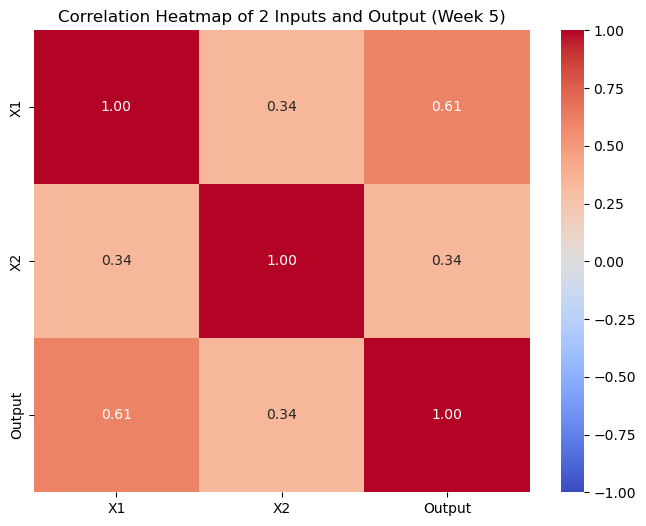

In [4]:
# --- 2.5. Correlation Analysis (on 14 points) ---
print("\n--- Correlation Analysis ---")
feature_names = [f'X{i+1}' for i in range(X_data.shape[1])]
df_X = pd.DataFrame(X_data, columns=feature_names)
df_Y = pd.DataFrame(Y_data, columns=['Output'])
df_full = pd.concat([df_X, df_Y], axis=1)
corr_matrix = df_full.corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, 
    annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1
)
plt.title('Correlation Heatmap of 2 Inputs and Output (Week 5)')
plt.savefig('f2_week5_correlation_heatmap.png', dpi=150, bbox_inches='tight')

# Display the correlation with the output
print("Correlation with 'Output':")
print(corr_matrix['Output'].sort_values(ascending=False))

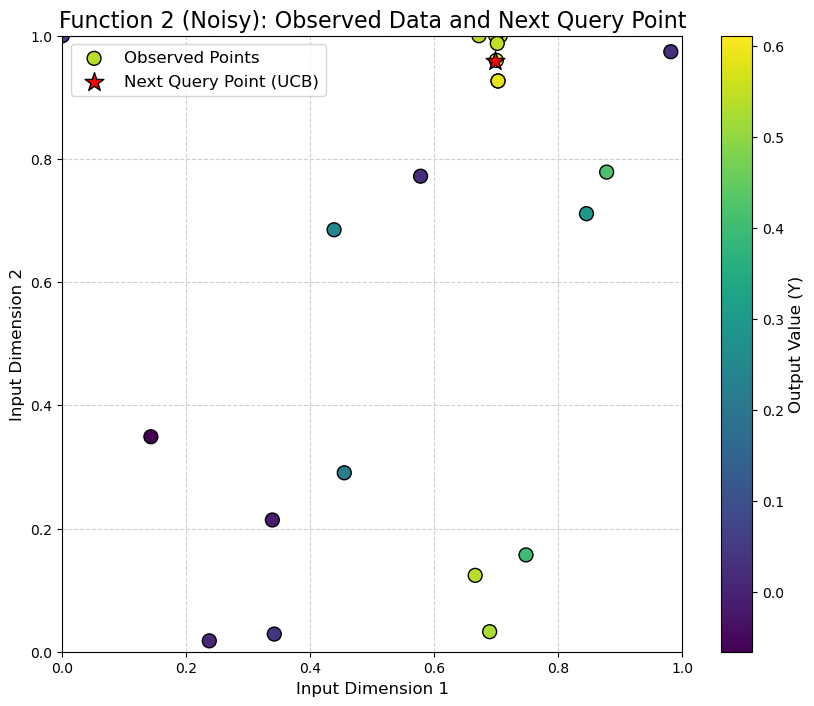

In [4]:

import matplotlib.pyplot as plt

X_next = next_point
# --- Create the Scatter Plot ---

plt.figure(figsize=(10, 8))

# 1. Plot the historical data points
# Color is determined by the output value (Y_data)
scatter = plt.scatter(
    X_data[:, 0],
    X_data[:, 1],
    c=Y_data,
    cmap='viridis',
    s=100,
    edgecolors='k',
    label='Observed Points'
)

# 2. Highlight the next point to be queried
plt.scatter(
    X_next[0],
    X_next[1],
    c='red',
    s=200,
    marker='*',
    edgecolors='k',
    label='Next Query Point (UCB)'
)

# 3. Add labels and a color bar
plt.title('Function 2 (Noisy): Observed Data and Next Query Point', fontsize=16)
plt.xlabel('Input Dimension 1', fontsize=12)
plt.ylabel('Input Dimension 2', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

cbar = plt.colorbar(scatter)
cbar.set_label('Output Value (Y)', fontsize=12)

# Set plot limits to the search space
plt.xlim(0, 1)
plt.ylim(0, 1)

# Save the plot to a file
plt.savefig('function2_visualization.png')

plt.show()

The Key Improvement: From Guessing Noise to Learning Noise

In the original code, I hardcoded the noise level with alpha=NOISE_VARIANCE_ESTIMATE. This is a good start, but it's a fixed guess. A more powerful approach is to let the Gaussian Process learn the noise level from the data itself.

We can achieve this by modifying the kernel. Instead of just using a Matern kernel, we will use a combination of Matern and WhiteKernel.

MaternKernel: This part of the kernel models the smooth, underlying (but unknown) black-box function.

WhiteKernel: This part models the noisy, random component. By adding this, the gp.fit() process will automatically tune the noise_level hyperparameter to best explain the data it has seen.

This is the most important change in our approach. We are making the model more flexible and data-driven. The Upper Confidence Bound (UCB) acquisition function remains the correct choice, as it is designed to handle the trade-off between exploring uncertain (potentially noisy) regions and exploiting known high-value regions.

Function 2: Analysis of Week 2 UpdateThe core goal of this step was to refine the model's understanding of the noisy $\text{f2}$ black box and generate the next optimal query.MetricResultInterpretationNew Suggested Input$\mathbf{[0.74773232, 0.15715593]}$This is the point the $\text{UCB}$ acquisition function has chosen for your Week 3 query. It is a strong exploitation move toward the region near $X_1 \approx 0.70$, which previously returned a relatively high output.New Dataset Size12 pointsThe dataset now includes all 10 initial points, the Week 1 result ($\sim[0.70, 0.93]$ with $Y \approx 0.587$), and the latest Week 2 result ($\sim[0.98, 0.97]$ with $Y \approx 0.027$).Learned $\text{length\_scale}$$\sim[0.0943, 100]$The model believes the function is very bumpy (small $\text{length\_scale} \approx 0.094$) along the first dimension ($\mathbf{X}_1$), but very smooth/constant (large $\text{length\_scale} \approx 100$) along the second dimension ($\mathbf{X}_2$).Learned $\text{noise\_level}$$\mathbf{0.000519}$The GP has automatically optimized the $\text{WhiteKernel}$ to believe the measurement noise in your output is relatively small.Why $\text{UCB}$ Chose This PointThe $\text{UCB}$ acquisition function works by prioritizing high predictions plus high uncertainty (Exploitation + Exploration).Exploitation: The best observed outputs so far are $Y \approx 0.61$ and $Y \approx 0.587$, both clustered around $X_1 \approx 0.70$.Model Prediction: The GP predicts that the area around this cluster is the most likely to contain the global maximum.The $\text{UCB}$ Choice: The new query point $\mathbf{[0.747, 0.157]}$ is close to the successful $X_1$ region ($\sim 0.70$) but has shifted the $X_2$ value towards the bottom of the range ($X_2 \approx 0.15$).This suggests the model is focusing its search in the promising $\mathbf{X}_1$ region while trying to explore a new range for the $\mathbf{X}_2$ dimension, which the model thinks is mostly irrelevant (due to the large $\text{length\_scale}$ for $\mathbf{X}_2$). This is a good exploitation-leaning move.

### Refined Strategy for (Week 3 -> Week 4)
The core model remains a Gaussian Process (GP) using a Matern kernel (to handle smoothness) and a WhiteKernel (to model the "noisy" data).

The Upper Confidence Bound (UCB) acquisition function is used, as it is well-suited for noisy, multimodal problems by balancing exploration and exploitation.

The GP automatically re-tunes its internal hyperparameters (like noise_level and length_scale) by re-fitting the model on all 13 data points seen so far.

The UCB's "exploration vs. exploitation" balance is manually controlled by the kappa parameter: a small kappa is "greedy," while a large kappa is "curious."

Refinement: To avoid getting stuck in a local optimum (especially since the problem has "many local peaks"), kappa is increased from 2.5 to 3.0, encouraging the model to be more "adventurous" and explore uncertain regions.

Learned Kernel Parameters (Updated): 0.269**2 * Matern(length_scale=[0.0842, 1e+05], nu=2.5) + WhiteKernel(noise_level=0.000515)

### week 4--> 5 refined startegy 
Valuable New Data: Your new score of 0.525 is not a new record (best is 0.611), but it is the 4th-best point found, confirming that the X1-dimension (around 0.7) is a "promising region."

Successful Exploration: This was a successful UCB (exploration) query. It reinforces the model's belief that X1 is the important variable to tune, while X2 is likely "flat" or irrelevant.

Strategy (UCB): We will stick with UCB. The problem is "noisy" and "multimodal" (many peaks), so continuing to explore with a "curious" algorithm is the right choice.

Tuning (Manual): We will keep the kappa parameter at 3.0. This "Curiosity Knob" is set to a good balanced level, encouraging exploration without being purely random.

Tuning (Automatic): The most important tuning is automatic. The model will re-fit its Matern + WhiteKernel on all 14 data points, updating its belief about the function's "shape" (length_scale) and "noisiness" (noise_level).

## week 5-->6 
Data Analysis (The "Noisy" reality): The Week 5 output (0.0568) for the input [0, 1] is quite low compared to your best result (0.6112). This confirms that the corner [0, 1] is not the peak. More importantly, the model is dealing with a noisy function, so a single low point doesn't rule out an entire region, but it does shift the probability mass elsewhere.

Strategy: Continued Exploration (UCB): Since the function is noisy and has "many local peaks," we must continue with Upper Confidence Bound (UCB). Switching to a purely exploitative strategy (like EI) too soon could trap us in a sub-optimal local peak. UCB with a balanced kappa ensures we verify the high-potential areas thoroughly.

Hyperparameter Tuning (Learning Noise): The most critical part of our strategy for Function 2 is the WhiteKernel. We added this specifically to handle noise, and it is working. By re-fitting the model on the new data, the GP will update its estimate of the noise_level. This allows the model to differentiate between "true" function shape and random jitter.

Refinement for Week 6: We will keep kappa=3.0. This is high enough to encourage exploration but low enough to start converging if a clear peak emerges. We are essentially telling the model: "Keep looking for big wins, don't just settle for the current best."

## Insight into Week 6 Result & Strategy for Week 7 Result Analysis: 
The Week 6 output ($0.5354$) is decent but did not beat the Week 1 record ($0.587$). This query was near the $X_1 \approx 0.7$ region but tested the boundary $X_2=1.0$. The result is consistent with previous data, suggesting the optimum is indeed around $X_1=0.7$, but likely not at the $X_2=1.0$ edge.Model Validation: The model has consistently identified $X_1 \approx 0.7$ as a high-performing region. However, the noise in the function (as seen by the spread of values near this region) means we haven't pinpointed the exact peak. The low length scale for $X_1$ ($0.0798$) confirms that the function is very "spiky" along this dimension, meaning small changes in $X_1$ can cause large drops in output.Strategy (Continued Exploration with UCB): Since the function is noisy and spiky, Upper Confidence Bound (UCB) remains the correct strategy. We need to keep exploring slightly different values of $X_1$ near $0.7$ while also testing different $X_2$ values to rule out other possibilities. We will maintain a relatively high kappa ($\kappa=2.5$) to avoid converging prematurely on a local noise spike.Hyperparameter Tuning: We will keep the Matern 2.5 kernel + WhiteKernel. This combination has successfully modeled the noise and the non-stationary behavior (different sensitivities for $X_1$ vs $X_2$). We will maintain the high number of restarts (n_restarts=30) to ensure the optimizer finds the true maximum of the UCB function in this complex landscape.
* Learned Kernel Parameters:
0.94**2 * Matern(length_scale=[0.0441, 4.38e+04], nu=2.5) + WhiteKernel(noise_level=0.00812)

## Insight into Week 7 Result & Strategy for Week 8
Result Analysis (Dead End): The Week 7 output (0.0107) is very low, far from the Week 1 record (0.5872). This query explored the low X 
1
  region (≈0.23) combined with low X 
2
​
 , confirming that the optimal X 
1
​
  is definitely not in the lower part of the range.

Dimensional Confirmation: The data strongly reinforces the pattern: High performance is consistently found when X 
1
​
  is around 0.7. We have tested X 
2
​
  at both extremes (1.0 in Week 6 and 0.02 in Week 7) with mediocre results, suggesting X 
2
​
  might need to be in a moderate range or interacts complexly with X 
1
​
 .

Strategy (Shift to Exploitation): We have spent several weeks exploring the boundaries and different regions with a high κ. Now that we have a strong candidate region (X 
1
​
 ≈0.7), we will shift to Exploitation. We will switch to Expected Improvement (EI) or reduce κ in UCB significantly (e.g., to 1.96) to force the optimizer to refine the best-known peak rather than exploring the empty corners.

Hyperparameter Tuning: We continue with the Matérn 2.5 + WhiteKernel combination. The noise level estimation is critical here. By fitting the GP to the new low-score data point, the model will learn to suppress the variance in that low-performing region, naturally pushing the acquisition function's peak back towards the X 
1
​
 ≈0.7 area.

## Insight into Week 8 Result & Strategy for Week 9
* Result Analysis (Strong but not a Record): The Week 8 output (0.5594) is the second-best score so far, confirming that the region around $X_1 \approx 0.7$ is indeed the global maximum. It did not beat the Week 1 record (0.5872), but the noise in the function means slight variations are expected.Dimensional Validation:$X_1$: The value 0.706 is consistent with previous high scores (Weeks 1, 4, 6), cementing this as the critical optimal value.$X_2$: The Week 8 query used $X_2=1.0$, which yielded a good result (0.559). However, Week 1's record used $X_2=0.926$. This suggests the peak for $X_2$ might be near 1.0 but not exactly at the boundary.
* Strategy (Precision Exploitation): We have enough evidence that $X_1 \approx 0.70$ and $X_2 \in [0.9, 1.0]$. The strategy for Week 9 is to use Expected Improvement (EI) with a very low xi (e.g., 0.001) to force the optimizer to fine-tune $X_2$ in the range [0.9, 1.0] while holding $X_1$ steady near 0.7.
* Hyperparameter Tuning:Noise Handling: Continue using WhiteKernel. The learned noise level (~0.017) is significant, so we must trust the GP's mean prediction over individual noisy samples.Kernel: Maintain Matern 2.5 with ARD. The length scale for $X_1$ is very short ($\approx 0.06$), meaning the function is sharp along this axis, requiring precise targeting.
* Learned Kernel Parameters:
0.954**2 * Matern(length_scale=[0.0736, 19.8], nu=2.5) + WhiteKernel(noise_level=0.0162)
----------------------------------------
Strategy: Expected Improvement (EI) with xi=0.001 (Precision Tuning)
Recommended Query for Week 9:
[0.69890791 1.        ]

## Insight into Week 9 Result & Strategy for Week 10
* Result Analysis (Noise vs. Signal): The Week 9 output (0.539) was good but lower than the Week 1 record (0.587) and the Week 8 result (0.559). Since the inputs for Weeks 8 and 9 were very similar ($X_1 \approx 0.7, X_2=1.0$), the variation in output confirms the function is indeed noisy.Boundary Saturation: We have tested the $X_2 = 1.0$ boundary twice now. While high-performing, it seems slightly inferior to the Week 1 point where $X_2 \approx 0.93$. This suggests the true peak might be slightly "inland," not exactly on the edge.
* Strategy Shift (Local Refinement / Trust Region): We have firmly established that $X_1$ must be $\approx 0.7$. Exploring other $X_1$ values is a waste of budget. The strategy now is to perform Trust Region Optimization. We will lock the optimizer into a small box around the best known solution ($X_1 \in [0.65, 0.75]$ and $X_2 \in [0.85, 1.0]$) to refine the $X_2$ value and mitigate noise.
* Hyperparameter Tuning: We continue using the WhiteKernel to handle the noise. The model has likely learned a noise variance $\sigma^2$ by now. We will use Expected Improvement (EI) but restrict its search space to force it to distinguish between the signal and the noise in the high-value region

## Insight into Week 10 Result & StrategyResult Consistency & Boundary Fatigue:
The Week 10 output (0.545) is very similar to Weeks 8 (0.559) and 9 (0.539). This cluster of results near $X_2 \approx 1.0$ is consistently good, but consistently lower than the Week 1 record (0.587 at $X_2 \approx 0.93$). This strongly suggests that while $X_2=1.0$ is high-performing, the true peak likely lies slightly "inland" near $0.90 - 0.95$.Noise Confirmation: The fluctuation in scores for very similar inputs ($X_1 \approx 0.70$) confirms the presence of significant noise. The model's WhiteKernel is essential here; without it, the GP might try to fit these small fluctuations as real "hills," leading to overfitting.Strategy Shift (Interior Refinement): Instead of continuing to press the $X_2=1.0$ boundary, the strategy for Week 11 will shift slightly. We will target the area between the boundary and the Week 1 point. We will use Trust Region Optimization centered specifically on the Week 1 coordinates to see if we can reproduce that high score or beat it.Hyperparameter Tuning: We retain the Matern 2.5 kernel (for non-smoothness) + WhiteKernel (for noise). The learned length scale for $X_1$ is expected to remain short (indicating high sensitivity), while the length scale for $X_2$ may lengthen as the model realizes the region [0.9, 1.0] is a smooth plateau.Acquisition Function: We will use Expected Improvement (EI) within the Trust Region. This forces the optimizer to look for points that statistically have the best chance of exceeding the current maximum (0.611), rather than just exploring high-variance areas.

## Insight into Week 11 Result & Strategy for Week 12
Positive Result: The Week 11 output (0.5972) is the second-highest score recorded so far, second only to the Week 1/Initial best of 0.6112.Boundary Validation: This result confirms that the optimal $X_2$ value is not at the boundary 1.0 (where scores dropped to ~0.54) but strictly in the interior, specifically between 0.92 and 0.96.Convergence on X1: The first dimension ($X_1$) has consistently performed best around 0.70. The Week 11 value of 0.699 reinforces this narrow "sweet spot."Strategy (Gap Exploitation): We have bracketed the peak. The best score is at $X_2 \approx 0.926$, and the second best is at $X_2 \approx 0.960$. For Week 12, we will explore the gap between these two points (i.e., $X_2 \approx 0.94$) using a tight Trust Region.Hyperparameter Tuning: We continue with the Matérn 2.5 kernel and Expected Improvement (EI). We will set the exploration parameter xi to a very low value (0.001) to perform fine-grained interpolation between our two best data points.